In [14]:
!pip install -qU \
langchain \
langchain-community \
langchain-text-splitters \
sentence-transformers \
faiss-cpu \
pymupdf \
openai \
streamlit \
fastapi \
uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [15]:
import fitz
import faiss
import langchain
import sentence_transformers
import openai
import streamlit
import fastapi

print("All libraries imported successfully!")

All libraries imported successfully!


In [16]:
from google.colab import files

uploaded = files.upload()

Saving Lec2.pdf to Lec2.pdf


In [17]:
import fitz

pdf_path = "Lec2.pdf"

doc = fitz.open(pdf_path)

print(f"Number of pages: {len(doc)}")

Number of pages: 26


In [18]:
pages = []

for page_num in range(len(doc)):
    page = doc.load_page(page_num)

    text = page.get_text()

    pages.append({
        "page": page_num + 1,
        "text": text,
        "source": pdf_path
    })

print(f"Successfully extracted {len(pages)} pages.")

Successfully extracted 26 pages.


In [19]:
pages[0]

{'page': 1,
 'text': 'Introduction to Generative AI & LLMs\nEmbedding Concept 2 / intro to Transformers\nالذكاء الصنعي العملي\nالمحاضرة الثانية\nكلية الهندسة\nد .رياض سنبل\n1\nRIAD SONBOL - ML COURSE\n',
 'source': 'Lec2.pdf'}

In [20]:
print(pages[0]["text"])

Introduction to Generative AI & LLMs
Embedding Concept 2 / intro to Transformers
الذكاء الصنعي العملي
المحاضرة الثانية
كلية الهندسة
د .رياض سنبل
1
RIAD SONBOL - ML COURSE



In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [22]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=200,
    length_function=len
)

In [23]:
from langchain_core.documents import Document

documents = []

for page in pages:
    documents.append(
        Document(
            page_content=page["text"],
            metadata={
                "page": page["page"],
                "source": page["source"]
            }
        )
    )

print(f"Created {len(documents)} Document objects.")

Created 26 Document objects.


In [24]:
chunks = text_splitter.split_documents(documents)

print(f"Number of chunks: {len(chunks)}")

Number of chunks: 26


In [25]:
print(chunks[0].page_content)

Introduction to Generative AI & LLMs
Embedding Concept 2 / intro to Transformers
الذكاء الصنعي العملي
المحاضرة الثانية
كلية الهندسة
د .رياض سنبل
1
RIAD SONBOL - ML COURSE


In [26]:
print(chunks[0].metadata)

{'page': 1, 'source': 'Lec2.pdf'}


In [27]:
for i in range(3):
    print("=" * 60)
    print(f"Chunk {i + 1}")
    print("=" * 60)
    print(chunks[i].page_content)
    print("\nMetadata:", chunks[i].metadata)

Chunk 1
Introduction to Generative AI & LLMs
Embedding Concept 2 / intro to Transformers
الذكاء الصنعي العملي
المحاضرة الثانية
كلية الهندسة
د .رياض سنبل
1
RIAD SONBOL - ML COURSE

Metadata: {'page': 1, 'source': 'Lec2.pdf'}
Chunk 2
Word Embedding
▪An embedding maps each word to a point in a much smaller m-dim space (e.g. 
300 values)
▪Two approaches:
◦Learn the embedding jointly with your main task:
◦An embedding layer with m hidden nodes to map word IDs to an m-dim 
vector.
◦Add your hidden layer and output layer, learn weights end-to-end with SGD.
◦Use pre-trained embedding:
◦Usually trained on another, much bigger dataset.
◦Freeze embedding weights to produce simple word embedding.
RIAD SONBOL - NLP COURSE
2

Metadata: {'page': 2, 'source': 'Lec2.pdf'}
Chunk 3
Training Embedding Layer
▪Input layer use fixed length document (e.g. 100 nodes for 100 word IDs).
◦Pad with 0’s is doc is shorter.
▪Add an embedding layer to learn embeddings:
◦(1) Represent every word as an n-dim one hot enc

In [28]:
!pip install -q langchain-huggingface

In [29]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

print("Model loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [30]:
text = "Retrieval-Augmented Generation improves factual accuracy."

embedding = embedding_model.encode(text)

print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [31]:
chunk_texts = [chunk.page_content for chunk in chunks]

chunk_embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True
)

print(chunk_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(26, 384)


In [32]:
print(type(embedding_model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [33]:
text = "Retrieval-Augmented Generation improves factual accuracy."

embedding = embedding_model.encode(text)

print(type(embedding))
print(embedding.shape)
print(embedding[:10])

<class 'numpy.ndarray'>
(384,)
[-0.00569989  0.02284812  0.01345086 -0.02127782  0.05084766  0.06042905
 -0.0312824   0.01480602  0.01606466  0.0160988 ]


In [34]:
chunk_texts = [chunk.page_content for chunk in chunks]

chunk_embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding matrix shape:", chunk_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix shape: (26, 384)


In [35]:
import faiss
import numpy as np

print("FAISS imported successfully!")

FAISS imported successfully!


In [36]:
print(chunk_embeddings.shape)

(26, 384)


In [37]:
dimension = chunk_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

print("FAISS index created!")

FAISS index created!


In [38]:
index.add(
    np.array(chunk_embeddings)
)

print("Number of vectors in FAISS:", index.ntotal)

Number of vectors in FAISS: 26


In [39]:
faiss.write_index(
    index,
    "research_faiss.index"
)

print("FAISS database saved!")

FAISS database saved!


In [40]:
import pickle

with open("chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print("Chunks saved!")

Chunks saved!


In [41]:
query = "What is skip-grams?"

In [42]:
query_embedding = embedding_model.encode(
    [query]
)

In [43]:
distances, indices = index.search(
    query_embedding,
    k=3
)

print(indices)
print(distances)

[[4 6 7]]
[[0.4354158  0.66796756 0.7396099 ]]


In [44]:
for idx in indices[0]:
    print("="*50)
    print(chunks[idx].page_content)
    print(chunks[idx].metadata)

Skip-grams
▪We can also analyze the meaning of a particular word by looking at 
the contexts in which it occurs. 
▪The context is the set of words that occur near the word, i.e. at 
displacements of …,-3,-2,-1,+1,+2,+3,… in each sentence where the 
word occurs. 
▪A skip-gram is a set of non-consecutive words (with specified 
offset), that occur in some sentence. 
▪We can construct a BoSG (bag of skip-gram) representation for 
each word from the skip-gram table.
◦Example?
{'page': 5, 'source': 'Lec2.pdf'}
The skip-gram model
•
Vocabulary size: V
•
Input layer: center word in 1-hot form.        
•
k-th row of WVxN is center vector of k-th word. 
•
k-th column of W’NXV is context vector of the 
k-th word in V. 
•
Note, each word has 2 vectors, both 
randomly initialized.
•
The output column yij, i=1..C, has 3 steps
      1) Use the context word 1-hot vector to 
           choose its column in W’NxV
          2) dot product with hi the center word
       3) compute the softmax
RIAD SONBOL 

In [45]:
!pip install -q python-dotenv

In [46]:
from google.colab import userdata

In [47]:
import os
from google.colab import userdata

os.environ["OPENROUTER_API_KEY"] = userdata.get(
    "OPENROUTER_API_KEY"
)

print("API key loaded!")

API key loaded!


In [48]:
!pip install -q openai

In [49]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"]
)

print("OpenRouter connected!")

OpenRouter connected!


In [50]:
response = client.chat.completions.create(
    model="meta-llama/llama-3.1-8b-instruct",
    messages=[
        {
            "role": "user",
            "content": "Explain what AI is in one sentence."
        }
    ]
)

print(response.choices[0].message.content)

Artificial intelligence (AI) refers to a system or technology that enables a machine or computer to perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and recognizing patterns, through algorithms and data processing.


In [51]:
def retrieve_documents(query, k=3):

    query_embedding = embedding_model.encode(
        [query]
    )

    distances, indices = index.search(
        query_embedding,
        k
    )

    retrieved_chunks = []

    for idx in indices[0]:
        retrieved_chunks.append(
            chunks[idx]
        )

    return retrieved_chunks

In [52]:
query = "What is skip-gram?"

results = retrieve_documents(query)

print(len(results))

3


In [53]:
for i, doc in enumerate(results):

    print("="*60)
    print("RESULT", i+1)
    print(doc.page_content[:500])
    print(doc.metadata)

RESULT 1
Skip-grams
▪We can also analyze the meaning of a particular word by looking at 
the contexts in which it occurs. 
▪The context is the set of words that occur near the word, i.e. at 
displacements of …,-3,-2,-1,+1,+2,+3,… in each sentence where the 
word occurs. 
▪A skip-gram is a set of non-consecutive words (with specified 
offset), that occur in some sentence. 
▪We can construct a BoSG (bag of skip-gram) representation for 
each word from the skip-gram table.
◦Example?
{'page': 5, 'source': 'Lec2.pdf'}
RESULT 2
The skip-gram model
•
Vocabulary size: V
•
Input layer: center word in 1-hot form.        
•
k-th row of WVxN is center vector of k-th word. 
•
k-th column of W’NXV is context vector of the 
k-th word in V. 
•
Note, each word has 2 vectors, both 
randomly initialized.
•
The output column yij, i=1..C, has 3 steps
      1) Use the context word 1-hot vector to 
           choose its column in W’NxV
          2) dot product with hi the center word
       3) compute the so

In [54]:
def create_prompt(question, documents):

    context = ""

    for doc in documents:
        context += (
            f"\nSource: {doc.metadata}\n"
            f"{doc.page_content}\n"
        )

    prompt = f"""
You are an AI research assistant.

Answer the question using ONLY the provided context.

If the answer is not in the context, say:
"I cannot find this information in the documents."

Context:
------------------
{context}
------------------

Question:
{question}

Answer:
"""

    return prompt

In [55]:
question = "What time is it?"

docs = retrieve_documents(question)

prompt = create_prompt(
    question,
    docs
)

print(prompt[:2000])


You are an AI research assistant.

Answer the question using ONLY the provided context.

If the answer is not in the context, say:
"I cannot find this information in the documents."

Context:
------------------

Source: {'page': 6, 'source': 'Lec2.pdf'}
word2Vec: Local contexts
▪Instead of entire documents, Word2Vec uses words k positions 
away from each center word.
◦These words are called context words.
▪Example for k=3:
◦“It was a bright cold day in April, and the clocks were striking”.
◦Center word: red (also called focus word).
◦Context words: blue (also called target words).
▪Word2Vec considers all words as center words, and all their context 
words.
6

Source: {'page': 9, 'source': 'Lec2.pdf'}
9
0
1
0
0
0
0
0
0
…
0
0
0
0
1
0
0
0
0
…
0
cat
on
0
0
0
0
0
0
0
1
…
0
Input layer
Hidden layer
sat
Output layer
𝑊𝑉×𝑁
𝑊𝑉×𝑁
V-dim
V-dim
N-dim
𝑊′𝑁×𝑉
V-dim
N will be the size of word vector
We must learn W and W’ 
www.cs.ucr.edu/~vagelis/classes/CS242/slides/word2vec.pptx
Example

Source: {'pa

In [56]:
def ask_rag(question):

    documents = retrieve_documents(
        question,
        k=3
    )

    prompt = create_prompt(
        question,
        documents
    )

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-8b-instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    answer = response.choices[0].message.content

    return answer, documents

In [57]:
answer, sources = ask_rag(
    "Explain CBOW."
)

print(answer)

According to the provided context, CBOW (Continuous Bag Of Words) is a model that predicts the center word given a context word, which is opposite to the skip-gram model. This is also the Continuous Bag Of Words model as described in the original Word2Vec paper.


In [58]:
for doc in sources:

    print(
        "Page:",
        doc.metadata["page"]
    )

    print(
        doc.page_content[:300]
    )

    print("-"*50)

Page: 11
11
0
1
0
0
0
0
0
0
…
0
0
0
0
1
0
0
0
0
…
0
xcat
xon
0
0
0
0
0
0
0
1
…
0
Input layer
Hidden layer
sat
Output layer
V-dim
V-dim
N-dim
V-dim
+
ො𝑣= 𝑣𝑐𝑎𝑡+ 𝑣𝑜𝑛
2
0.1
2.4
1.6
1.8
0.5
0.9
…
…
…
3.2
0.5
2.6
1.4
2.9
1.5
3.6
…
…
…
6.1
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
0.6
1.8
2.7
1.9
2.4
2.0
…
…
…
1.2
×

--------------------------------------------------
Page: 10
10
0
1
0
0
0
0
0
0
…
0
0
0
0
1
0
0
0
0
…
0
xcat
xon
0
0
0
0
0
0
0
1
…
0
Input layer
Hidden layer
sat
Output layer
V-dim
V-dim
N-dim
V-dim
+
ො𝑣= 𝑣𝑐𝑎𝑡+ 𝑣𝑜𝑛
2
0.1
2.4
1.6
1.8
0.5
0.9
…
…
…
3.2
0.5
2.6
1.4
2.9
1.5
3.6
…
…
…
6.1
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
…
0.6
1.8
2.7
1.9
2.4
2.0
…
…
…
1.2
×

--------------------------------------------------
Page: 8
CBOW 
• What about we predict center 
word, given context word, 
opposite to the skip-gram model?
• Yes, this is called Continuous Bag 
Of Words model in the original 
Word2Vec paper.
--------------------------------------------------


In [59]:
def ask_rag(question):

    documents = retrieve_documents(
        question,
        k=3
    )

    prompt = create_prompt(
        question,
        documents
    )

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-8b-instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    answer = response.choices[0].message.content

    sources = []

    for doc in documents:
        sources.append({
            "source": doc.metadata["source"],
            "page": doc.metadata["page"]
        })

    return answer, sources

In [60]:
answer, sources = ask_rag(
    "Explain the main concept of this lecture."
)

print(answer)

print("\nSources:")
for source in sources:
    print(source)

According to the introduction on page 1 of 'Lec2.pdf', the main concept of this lecture is "Introduction to Generative AI & LLMs".

Sources:
{'source': 'Lec2.pdf', 'page': 26}
{'source': 'Lec2.pdf', 'page': 17}
{'source': 'Lec2.pdf', 'page': 1}


In [61]:
def create_advanced_prompt(question, documents):

    context = ""

    for i, doc in enumerate(documents):

        context += f"""
Document {i+1}
Source: {doc.metadata['source']}
Page: {doc.metadata['page']}

{doc.page_content}

-----------------------
"""

    prompt = f"""
You are an AI research assistant.

Your task is to answer questions based ONLY on the provided context.

Rules:
1. Do not use outside knowledge.
2. If the answer is not present in the context, say:
   "I cannot find this information in the provided documents."
3. Explain concepts clearly.
4. Include important details from the sources.
5. Mention the source pages when possible.

Context:
========================

{context}

========================

Question:
{question}

Answer:
"""

    return prompt

In [62]:
question = "What is retrieval augmented generation?"

docs = retrieve_documents(question)

prompt = create_advanced_prompt(
    question,
    docs
)

print(prompt[:3000])


You are an AI research assistant.

Your task is to answer questions based ONLY on the provided context.

Rules:
1. Do not use outside knowledge.
2. If the answer is not present in the context, say:
   "I cannot find this information in the provided documents."
3. Explain concepts clearly.
4. Include important details from the sources.
5. Mention the source pages when possible.

Context:


Document 1
Source: Lec2.pdf
Page: 1

Introduction to Generative AI & LLMs
Embedding Concept 2 / intro to Transformers
الذكاء الصنعي العملي
المحاضرة الثانية
كلية الهندسة
د .رياض سنبل
1
RIAD SONBOL - ML COURSE

-----------------------

Document 2
Source: Lec2.pdf
Page: 25

Contextual Embedding
RIAD SONBOL - NLP COURSE
25

-----------------------

Document 3
Source: Lec2.pdf
Page: 24

Initial Embedding
RIAD SONBOL - NLP COURSE
24

-----------------------



Question:
What is retrieval augmented generation?

Answer:



In [63]:
def ask_rag_v2(question):

    documents = retrieve_documents(
        question,
        k=3
    )

    prompt = create_advanced_prompt(
        question,
        documents
    )

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-8b-instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    answer = response.choices[0].message.content

    return answer, documents

In [64]:
answer, docs = ask_rag_v2(
    "Explain the main idea of this lecture."
)

print(answer)

Based on the given context, it appears that this lecture series is covering Machine Learning (ML) and Natural Language Processing (NLP) topics. 

The main idea of this lecture can be inferred from:

- Document 3, Page 1, mentions "Introduction to Generative AI & LLMs," indicating that this lecture is an introduction to generative artificial intelligence and large language models.
- Document 3, Page 1, also mentions "Embedding Concept 2 / intro to Transformers," suggesting that this lecture will cover the transformer concept.
- Document 2, Page 17, confirms this by stating "Transformer / In General," indicating that the main topic of this lecture is the transformer, which is a key concept in NLP and ML.

Therefore, the main idea of this lecture is likely an introduction to the transformer in the context of generative AI and large language models.


In [65]:
for doc in docs:
    print(doc.metadata)

{'page': 26, 'source': 'Lec2.pdf'}
{'page': 17, 'source': 'Lec2.pdf'}
{'page': 1, 'source': 'Lec2.pdf'}


In [66]:
chat_history = []

In [67]:
def add_to_history(role, content):

    chat_history.append(
        {
            "role": role,
            "content": content
        }
    )

In [68]:
def format_history():

    history_text = ""

    for message in chat_history:

        history_text += (
            f"{message['role']}: "
            f"{message['content']}\n"
        )

    return history_text

In [69]:
def create_memory_prompt(question, documents):

    context = ""

    for doc in documents:

        context += f"""
Source:
{doc.metadata}

{doc.page_content}

----------------
"""


    history = format_history()


    prompt = f"""
You are an AI research assistant.

Answer ONLY using the provided document context.

Conversation history:
====================

{history}

====================

Document context:
====================

{context}

====================

Current question:
{question}

Answer:
"""

    return prompt

In [70]:
def ask_rag_v3(question):

    documents = retrieve_documents(
        question,
        k=3
    )


    prompt = create_memory_prompt(
        question,
        documents
    )


    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-8b-instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )


    answer = response.choices[0].message.content


    add_to_history(
        "user",
        question
    )

    add_to_history(
        "assistant",
        answer
    )


    return answer, documents

In [71]:
answer, docs = ask_rag_v3(
    "Explain CBOW."
)

print(answer)

The Continuous Bag Of Words (CBOW) model is a variation of the Word2Vec algorithm where the task is to predict the center word given the context words, which is the opposite of the skip-gram model described in the original Word2Vec paper.


In [72]:
answer, docs = ask_rag_v3(
    "What are its main advantages?"
)

print(answer)

Unfortunately, the provided document context does not mention the specific advantages of the Continuous Bag Of Words (CBOW) model. The previous conversation only mentioned the model, and the provided documents only contain slide information about the Word2Vec algorithm and a course schedule. There is no information about the advantages of CBOW specific to the question.


In [73]:
chat_history

[{'role': 'user', 'content': 'Explain CBOW.'},
 {'role': 'assistant',
  'content': 'The Continuous Bag Of Words (CBOW) model is a variation of the Word2Vec algorithm where the task is to predict the center word given the context words, which is the opposite of the skip-gram model described in the original Word2Vec paper.'},
 {'role': 'user', 'content': 'What are its main advantages?'},
 {'role': 'assistant',
  'content': 'Unfortunately, the provided document context does not mention the specific advantages of the Continuous Bag Of Words (CBOW) model. The previous conversation only mentioned the model, and the provided documents only contain slide information about the Word2Vec algorithm and a course schedule. There is no information about the advantages of CBOW specific to the question.'}]

In [74]:
import os

os.makedirs("Research_RAG_App", exist_ok=True)

print("Project folder created")

Project folder created


In [75]:
os.chdir("Research_RAG_App")

print(os.getcwd())

/content/Research_RAG_App


In [76]:
os.makedirs("vector_store", exist_ok=True)
os.makedirs("uploaded_docs", exist_ok=True)

print("Folders created!")

Folders created!


In [77]:
open("rag_engine.py", "w").close()
open("embeddings.py", "w").close()
open("requirements.txt", "w").close()

print("Files created!")

Files created!


In [78]:
open("app.py", "w").close()

print("app.py created!")

app.py created!


In [79]:
!ls -R

.:
app.py	       rag_engine.py	 uploaded_docs
embeddings.py  requirements.txt  vector_store

./uploaded_docs:

./vector_store:


In [80]:
%%writefile embeddings.py

from sentence_transformers import SentenceTransformer


embedding_model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)


def get_embedding_model():

    return embedding_model

Overwriting embeddings.py


In [81]:
!ls

app.py	       rag_engine.py	 uploaded_docs
embeddings.py  requirements.txt  vector_store


In [82]:

faiss.write_index(
    index,
    "vector_store/research_faiss.index"
)

with open(
    "vector_store/chunks.pkl",
    "wb"
) as f:
    pickle.dump(chunks, f)

print("Vector database saved!")

Vector database saved!


In [83]:
%%writefile rag_engine.py

import os
import pickle
import faiss

from openai import OpenAI
from embeddings import get_embedding_model


embedding_model = get_embedding_model()


index = faiss.read_index(
    "vector_store/research_faiss.index"
)


with open(
    "vector_store/chunks.pkl",
    "rb"
) as f:
    chunks = pickle.load(f)



client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"]
)



def retrieve_documents(question, k=3):

    query_embedding = embedding_model.encode(
        [question]
    )

    distances, indices = index.search(
        query_embedding,
        k
    )

    documents = []

    for idx in indices[0]:

        documents.append(
            chunks[idx]
        )

    return documents



def create_prompt(question, documents):

    context = ""

    for doc in documents:

        context += f"""
Source:
{doc.metadata}

Content:
{doc.page_content}

-----------------
"""


    prompt = f"""
You are an AI research assistant.

Answer using ONLY the context below.

If the answer is not in the context,
say:
"I cannot find this information."

Context:
{context}


Question:
{question}


Answer:
"""

    return prompt



def ask_rag(question):

    documents = retrieve_documents(
        question
    )


    prompt = create_prompt(
        question,
        documents
    )


    response = client.chat.completions.create(

        model="meta-llama/llama-3.1-8b-instruct",

        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ]
    )


    answer = response.choices[0].message.content


    sources = []

    for doc in documents:

        sources.append(
            {
                "source": doc.metadata["source"],
                "page": doc.metadata["page"]
            }
        )


    return answer, sources

Overwriting rag_engine.py


In [84]:
from rag_engine import ask_rag

answer, sources = ask_rag(
    "What is CBOW"
)

print(answer)

print("\nSources:")
for source in sources:
    print(source)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Continuous Bag Of Words model.

Sources:
{'source': 'Lec2.pdf', 'page': 8}
{'source': 'Lec2.pdf', 'page': 11}
{'source': 'Lec2.pdf', 'page': 10}


In [85]:
%%writefile app.py

import streamlit as st
from rag_engine import ask_rag


st.set_page_config(
    page_title="AI Research Assistant",
    page_icon="📚",
    layout="wide"
)


st.title("📚 AI Research Assistant")

st.write(
    "Ask questions about your research documents."
)


question = st.text_input(
    "Enter your question:"
)


if st.button("Ask"):

    if question:

        with st.spinner("Searching documents..."):

            answer, sources = ask_rag(
                question
            )


        st.subheader("Answer")

        st.write(answer)


        st.subheader("Sources")

        for source in sources:

            st.write(
                f"📄 {source['source']} - Page {source['page']}"
            )

    else:

        st.warning(
            "Please enter a question."
        )

Overwriting app.py


In [86]:
!ls

app.py	       __pycache__    requirements.txt	vector_store
embeddings.py  rag_engine.py  uploaded_docs


In [87]:
!streamlit run app.py &>/content/logs.txt &

In [88]:
!pip install -q pyngrok
from pyngrok import ngrok

In [89]:
!ngrok config add-authtoken 3Gzv5gtXTIBv8yvokrft3HAcPUp_2pCc7d1sTV8MRtzvWoqaN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [90]:
!streamlit run app.py &>/content/logs.txt &

In [91]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://tipped-alto-handwork.ngrok-free.dev" -> "http://localhost:8501"


In [92]:
!ps aux | grep streamlit

root        3469 20.6  0.5 523988 69872 ?        Sl   18:08   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        3546  0.0  0.2  45784 35472 ?        R    18:08   0:00 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        3565  0.0  0.0   7376  3420 ?        S    18:08   0:00 /bin/bash -c ps aux | grep streamlit
root        3567  0.0  0.0   6484  2292 ?        S    18:08   0:00 grep streamlit


In [93]:
!pkill -f streamlit

In [94]:
!ps aux | grep streamlit

root        3469 19.2  0.5 523920 69952 ?        Sl   18:08   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        3572  0.0  0.0   7376  3424 ?        S    18:08   0:00 /bin/bash -c ps aux | grep streamlit
root        3574  0.0  0.0   6484  2392 ?        S    18:08   0:00 grep streamlit


In [95]:
!streamlit run app.py > /content/logs.txt 2>&1 &

In [96]:
!cat /content/logs.txt

In [97]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://tipped-alto-handwork.ngrok-free.dev" -> "http://localhost:8501"


In [98]:
!cat /content/logs.txt

In [99]:
from pyngrok import ngrok

ngrok.kill()

print("Old tunnels closed")

Old tunnels closed


In [101]:
public_url = ngrok.connect(
    8501,
    "http"
)

print(public_url)

NgrokTunnel: "https://tipped-alto-handwork.ngrok-free.dev" -> "http://localhost:8501"


In [102]:
!curl localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [124]:
evaluation_data = [
    {
        "question": "What is a word embedding?",
        "expected_answer": "A word embedding is a dense vector representation of a word."
    },
    {
        "question": "What is Word2Vec?",
        "expected_answer": "Word2Vec is a neural network model that learns distributed vector representations of words."
    },
    {
        "question": "What is the Skip-Gram model?",
        "expected_answer": "Skip-Gram predicts surrounding words given the current word."
    },
    {
        "question": "What is the CBOW model?",
        "expected_answer": "CBOW predicts the target word from its surrounding context words."
    },
    {
        "question": "What is FastText?",
        "expected_answer": "FastText represents words using character n-grams."
    },

    {
        "question": "What is CBOW?",
        "expected_answer": "the opposite of skip-grams."
    },
    {
        "question": "What is self-attention?",
        "expected_answer": "Self-attention determines how much attention each word should pay to every other word in the sequence."
    },


]

In [125]:
results = []

for sample in evaluation_data:

    answer, sources = ask_rag(sample["question"])

    results.append({
        "Question": sample["question"],
        "Expected Answer": sample["expected_answer"],
        "Generated Answer": answer,
        "Sources": sources
    })

print("Finished!")

Finished!


In [126]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

scores = []

for item in results:

    expected_embedding = embedding_model.encode(
        [item["Expected Answer"]]
    )

    generated_embedding = embedding_model.encode(
        [item["Generated Answer"]]
    )

    similarity = cosine_similarity(
        expected_embedding,
        generated_embedding
    )[0][0]

    scores.append(similarity)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [127]:
for i in range(len(results)):
    results[i]["Semantic Similarity"] = round(scores[i],3)

In [128]:
import pandas as pd

evaluation_df = pd.DataFrame(results)

evaluation_df

,Question,Expected Answer,Generated Answer,Sources,Semantic Similarity
0,What is a word embedding?,A word embedding is a dense vector representat...,A word embedding maps each word to a point in ...,"[{'source': 'Lec2.pdf', 'page': 2}, {'source':...",0.858
1,What is Word2Vec?,Word2Vec is a neural network model that learns...,Word2Vec uses words k positions away from a ce...,"[{'source': 'Lec2.pdf', 'page': 6}, {'source':...",0.757
2,What is the Skip-Gram model?,Skip-Gram predicts surrounding words given the...,The Skip-gram model is a model that predicts t...,"[{'source': 'Lec2.pdf', 'page': 7}, {'source':...",0.853
3,What is the CBOW model?,CBOW predicts the target word from its surroun...,The CBOW (Continuous Bag Of Words) model is a ...,"[{'source': 'Lec2.pdf', 'page': 8}, {'source':...",0.865
4,What is FastText?,FastText represents words using character n-gr...,FastText is a method that uses character n-gra...,"[{'source': 'Lec2.pdf', 'page': 16}, {'source'...",0.893
5,What is CBOW?,the opposite of skip-grams.,The CBOW model is a different approach from th...,"[{'source': 'Lec2.pdf', 'page': 8}, {'source':...",0.629
6,What is self-attention?,Self-attention determines how much attention e...,"In this context, self-attention is mentioned a...","[{'source': 'Lec2.pdf', 'page': 21}, {'source'...",0.719


In [129]:
average_score = np.mean(scores)

print(f"Average Semantic Similarity: {average_score:.3f}")

Average Semantic Similarity: 0.796


In [130]:
for row in results:

    print("="*80)

    print("Question:")
    print(row["Question"])

    print("\nRetrieved Sources:")

    for source in row["Sources"]:
        print(source)

Question:
What is a word embedding?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 2}
{'source': 'Lec2.pdf', 'page': 4}
{'source': 'Lec2.pdf', 'page': 3}
Question:
What is Word2Vec?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 6}
{'source': 'Lec2.pdf', 'page': 15}
{'source': 'Lec2.pdf', 'page': 16}
Question:
What is the Skip-Gram model?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 7}
{'source': 'Lec2.pdf', 'page': 5}
{'source': 'Lec2.pdf', 'page': 8}
Question:
What is the CBOW model?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 8}
{'source': 'Lec2.pdf', 'page': 10}
{'source': 'Lec2.pdf', 'page': 11}
Question:
What is FastText?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 16}
{'source': 'Lec2.pdf', 'page': 7}
{'source': 'Lec2.pdf', 'page': 5}
Question:
What is CBOW?

Retrieved Sources:
{'source': 'Lec2.pdf', 'page': 8}
{'source': 'Lec2.pdf', 'page': 11}
{'source': 'Lec2.pdf', 'page': 10}
Question:
What is self-attention?

Retrieved Sources:
{'source': 'Lec2.p

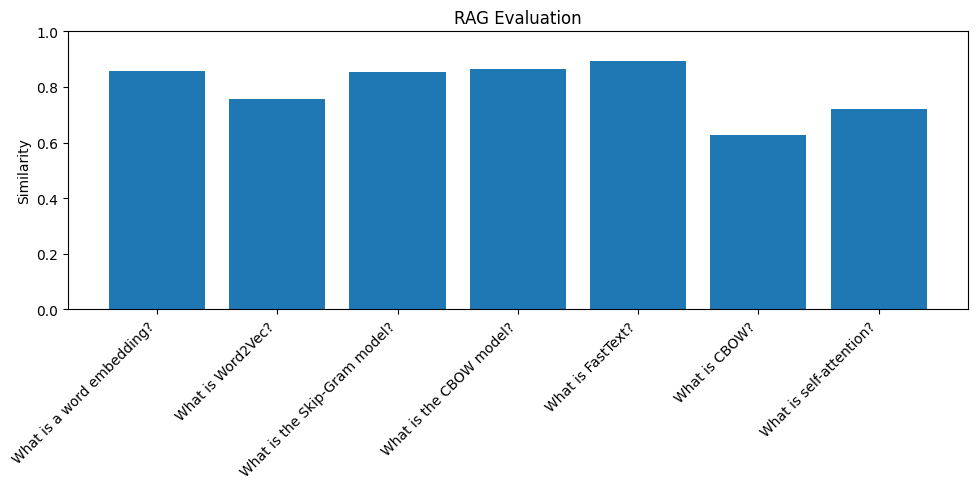

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    evaluation_df["Question"],
    evaluation_df["Semantic Similarity"]
)

plt.xticks(rotation=45, ha="right")

plt.ylim(0,1)

plt.ylabel("Similarity")

plt.title("RAG Evaluation")

plt.tight_layout()

plt.show()

In [132]:
evaluation_df.to_csv(
    "RAG_Evaluation.csv",
    index=False
)

print("Evaluation saved successfully!")

Evaluation saved successfully!
